# Target 10m Model Experiments Overview

Обзор результатов staged hold-out перебора моделей для `target_log_return_10m`.

Локальные входные файлы скачаны из:

`s3://binance-data-downloader/dataset_target_10/model_experiments/latest/`

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

In [7]:
from pathlib import Path
import json

from build_price_feature_day import make_s3_client

TARGET_HORIZON = 20  # 10, 20 или 30

BUCKET = "binance-data-downloader"
S3_PREFIX = f"dataset_target_{TARGET_HORIZON}/model_experiments/latest/"
LOCAL_DIR = Path(
    f"analysis/target_10_model_experiments/results/target_{TARGET_HORIZON}/latest"
)

FILES = [
    "experiment_results.parquet",
    "stage_selection.parquet",
    "run_config.json",
]

LOCAL_DIR.mkdir(parents=True, exist_ok=True)

s3 = make_s3_client()

for filename in FILES:
    s3_key = S3_PREFIX + filename
    local_path = LOCAL_DIR / filename
    print(f"Downloading s3://{BUCKET}/{s3_key} -> {local_path}")
    s3.download_file(BUCKET, s3_key, str(local_path))

RESULTS_DIR = LOCAL_DIR

run_config = json.loads((RESULTS_DIR / "run_config.json").read_text(encoding="utf-8"))

print("Done")
print("RESULTS_DIR =", RESULTS_DIR)
print("target =", run_config.get("target"))
print("run_id =", run_config.get("run_id"))

Done
RESULTS_DIR = analysis\target_10_model_experiments\results\target_20\latest
target = target_log_return_20m
run_id = 20260705_181404


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

# RESULTS_DIR = Path("analysis/target_10_model_experiments/results/latest")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("results/latest")

results = pd.read_parquet(RESULTS_DIR / "experiment_results.parquet")
stage_selection = pd.read_parquet(RESULTS_DIR / "stage_selection.parquet")
run_config = json.loads((RESULTS_DIR / "run_config.json").read_text(encoding="utf-8"))

results.shape, stage_selection.shape

((834, 42), (6, 9))

## Run Summary

In [9]:
summary_keys = [
    "run_id",
    "target",
    "direction_threshold",
    "train_rows",
    "test_rows",
    "n_jobs",
    "parallel_backend",
    "max_selected_per_stage",
]
pd.DataFrame(
    [{"field": key, "value": run_config.get(key)} for key in summary_keys]
)

,field,value
0,run_id,20260705_181404
1,target,target_log_return_20m
2,direction_threshold,0.0025
3,train_rows,2630700
4,test_rows,527040
5,n_jobs,24
6,parallel_backend,threading
7,max_selected_per_stage,6


In [10]:
stage_selection

,stage,stage_index,candidates,selected,selected_model_ids,n_jobs,parallel_backend,prep_time,prepared_features
0,stage_0_baseline,0,2,2,"[""stage_0_baseline_001_baseline_zero"", ""stage_0_baseline_002_baseline_mean""]",24,threading,2.274235,56
1,stage_1_ar,1,40,6,"[""stage_1_ar_004_lasso_alpha_1e_5"", ""stage_1_ar_005_lasso_alpha_1e_5"", ""stage_1_ar_004_ridge_alpha_10"", ""stage_1_ar_004_huber"", ""stage_1_ar_005_huber"", ""stage_1_ar_004_ols""]",24,threading,2.274235,56
2,stage_2_price_volatility,2,72,6,"[""stage_2_price_volatility_006_elasticnet_alpha_1e_4_l1_0_5"", ""stage_2_price_volatility_007_elasticnet_alpha_1e_4_l1_0_5"", ""stage_2_price_volatility_006_lasso_alpha_1e_5"", ""sta...",24,threading,2.274235,56
3,stage_3_microstructure,3,192,6,"[""stage_3_microstructure_016_lasso_alpha_1e_5"", ""stage_3_microstructure_008_lasso_alpha_1e_5"", ""stage_3_microstructure_007_lasso_alpha_1e_5"", ""stage_3_microstructure_020_huber""...",24,threading,2.274235,56
4,stage_4_btc,4,240,6,"[""stage_4_btc_011_lasso_alpha_1e_5"", ""stage_4_btc_013_lasso_alpha_1e_5"", ""stage_4_btc_006_lasso_alpha_1e_5"", ""stage_4_btc_024_huber"", ""stage_4_btc_023_huber"", ""stage_4_btc_025_...",24,threading,2.274235,56
5,stage_5_calendar_sessions,5,288,6,"[""stage_5_calendar_sessions_009_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_003_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_011_lasso_alpha_1e_5"", ""stage_5_calendar_session...",24,threading,2.274235,56


## Global Top Models

In [11]:
display_cols = [
    "model_id",
    "stage",
    "model_family",
    "feature_set",
    "n_features",
    "MAE",
    "RMSE",
    "Direction_Accuracy",
    "Direction_Accuracy_025",
    "DA_025_coverage",
    "OOS_R2",
    "Pearson_corr",
]

top_a = results.sort_values(
    ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
    ascending=[True, True, True, True, True],
).head(15)

top_b = results.sort_values(
    ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
    ascending=[False, True, True, True],
    na_position="last",
).head(15)

top_a[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
614,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+sessions,33,0.003809,0.007103,0.517322,0.521274,0.52281,0.018405,0.174965
566,stage_5_calendar_sessions_003_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+all_microstructure+btc_returns_only+sessions,31,0.003809,0.007103,0.516694,0.520977,0.52281,0.018457,0.175510
630,stage_5_calendar_sessions_011_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+day_sessions,36,0.003809,0.007103,0.517378,0.521322,0.52281,0.018396,0.174886
582,stage_5_calendar_sessions_005_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+all_microstructure+btc_returns_only+day_sessions,34,0.003809,0.007103,0.517121,0.521274,0.52281,0.018448,0.175435
662,stage_5_calendar_sessions_015_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+sessions,32,0.003809,0.007103,0.517865,0.521946,0.52281,0.018321,0.174476
678,stage_5_calendar_sessions_017_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+day_sessions,35,0.003809,0.007104,0.517840,0.521917,0.52281,0.018312,0.174393
622,stage_5_calendar_sessions_010_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+time_sessions,35,0.003809,0.007103,0.517075,0.521122,0.52281,0.018410,0.175008
574,stage_5_calendar_sessions_004_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+all_microstructure+btc_returns_only+time_sessions,33,0.003809,0.007103,0.516547,0.521198,0.52281,0.018461,0.175551
670,stage_5_calendar_sessions_016_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+time_sessions,34,0.003809,0.007103,0.517709,0.521728,0.52281,0.018326,0.174516
638,stage_5_calendar_sessions_012_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+all_calendar_sessions,38,0.003809,0.007103,0.517148,0.521238,0.52281,0.018403,0.174943


In [12]:
top_b[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
697,stage_5_calendar_sessions_019_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+time_of_day,36,0.003811,0.007112,0.520661,0.525176,0.52281,0.016084,0.131167
737,stage_5_calendar_sessions_024_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+all_calendar_sessions,41,0.003810,0.007107,0.521049,0.525143,0.52281,0.017318,0.137124
713,stage_5_calendar_sessions_021_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+sessions,36,0.003810,0.007108,0.520835,0.524983,0.52281,0.017209,0.136537
833,stage_5_calendar_sessions_036_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+all_btc+all_calendar_sessions,44,0.003810,0.007114,0.520479,0.524929,0.52281,0.015427,0.128373
721,stage_5_calendar_sessions_022_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+time_sessions,38,0.003810,0.007108,0.520871,0.524925,0.52281,0.017201,0.136575
729,stage_5_calendar_sessions_023_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+day_sessions,39,0.003810,0.007107,0.520852,0.524900,0.52281,0.017253,0.136712
809,stage_5_calendar_sessions_033_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+all_btc+sessions,39,0.003810,0.007114,0.520374,0.524849,0.52281,0.015457,0.128493
761,stage_5_calendar_sessions_027_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_returns_volatility+sessions,38,0.003810,0.007113,0.520249,0.524813,0.52281,0.015557,0.128841
817,stage_5_calendar_sessions_034_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+all_btc+time_sessions,41,0.003810,0.007114,0.520336,0.524806,0.52281,0.015408,0.128370
793,stage_5_calendar_sessions_031_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+all_btc+time_of_day,39,0.003810,0.007114,0.520015,0.524679,0.52281,0.015405,0.128261


## Best Model By Stage

In [13]:
best_mae_by_stage = (
    results.sort_values(["stage", "MAE", "RMSE", "n_features", "simplicity_rank"])
    .groupby("stage", as_index=False)
    .first()
)

best_da_by_stage = (
    results.sort_values(
        ["stage", "Direction_Accuracy_025", "n_features", "simplicity_rank"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("stage", as_index=False)
    .first()
)

best_mae_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.003814,0.007169,0.494714,0.000000,0.52281,0.000000,NaN
1,stage_1_ar_004_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_10,5,0.003813,0.007167,0.507209,0.508975,0.52281,0.000597,0.025433
2,stage_2_price_volatility_006_elasticnet_alpha_1e_4_l1_0_5,stage_2_price_volatility,elasticnet_alpha_1e_4_l1_0_5,baseline_zero+ar_10+trend_volatility,11,0.003809,0.007112,0.515898,0.519580,0.52281,0.015880,0.171766
3,stage_3_microstructure_016_lasso_alpha_1e_5,stage_3_microstructure,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure,29,0.003809,0.007104,0.516501,0.520799,0.52281,0.018264,0.173926
4,stage_4_btc_011_lasso_alpha_1e_5,stage_4_btc,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only,31,0.003809,0.007104,0.516501,0.520799,0.52281,0.018264,0.173926
5,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+sessions,33,0.003809,0.007103,0.517322,0.521274,0.52281,0.018405,0.174965


In [14]:
best_da_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.003814,0.007170,0.494714,0.492556,0.52281,-0.000047,NaN
1,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.003814,0.007167,0.508481,0.510605,0.52281,0.000555,0.027013
2,stage_2_price_volatility_009_huber,stage_2_price_volatility,huber,baseline_zero+ar_10+all_price_volatility,29,0.003811,0.007110,0.520013,0.523996,0.52281,0.016451,0.133422
3,stage_3_microstructure_020_huber,stage_3_microstructure,huber,baseline_zero+ar_10+all_price_volatility+concentration_only,33,0.003811,0.007111,0.520315,0.524359,0.52281,0.016204,0.131646
4,stage_4_btc_024_huber,stage_4_btc,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_returns_volatility,36,0.003810,0.007114,0.519868,0.524258,0.52281,0.015509,0.128728
5,stage_5_calendar_sessions_019_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+time_of_day,36,0.003811,0.007112,0.520661,0.525176,0.52281,0.016084,0.131167


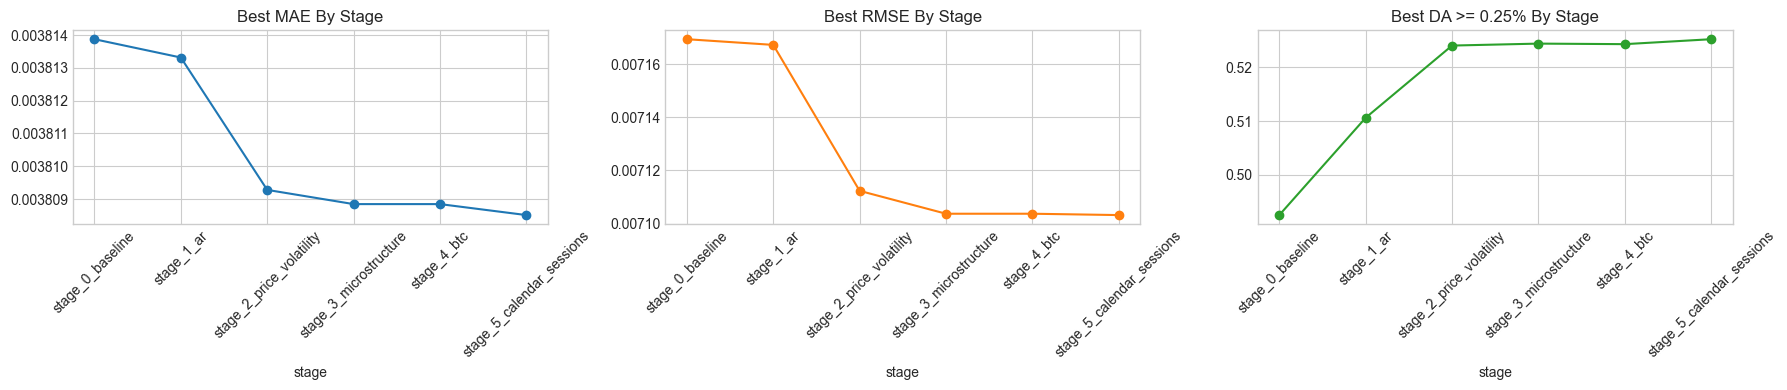

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

best_mae_by_stage.plot(x="stage", y="MAE", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Best MAE By Stage")
axes[0].tick_params(axis="x", rotation=45)

best_mae_by_stage.plot(x="stage", y="RMSE", marker="o", ax=axes[1], legend=False, color="tab:orange")
axes[1].set_title("Best RMSE By Stage")
axes[1].tick_params(axis="x", rotation=45)

best_da_by_stage.plot(x="stage", y="Direction_Accuracy_025", marker="o", ax=axes[2], legend=False, color="tab:green")
axes[2].set_title("Best DA >= 0.25% By Stage")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

## Added Block Informativeness

In [16]:
block_summary = (
    results.loc[results["stage"].ne("stage_0_baseline")]
    .groupby(["stage", "added_block"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_RMSE=("RMSE", "min"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        median_delta_MAE=("delta_MAE", "median"),
        median_delta_RMSE=("delta_RMSE", "median"),
        median_delta_DA_025=("delta_DA_025", "median"),
    )
    .sort_values(["stage", "best_MAE", "best_RMSE"])
)

block_summary

,stage,added_block,models,best_MAE,median_MAE,best_RMSE,best_DA_025,median_DA_025,best_OOS_R2,median_delta_MAE,median_delta_RMSE,median_delta_DA_025
1,stage_1_ar,ar_10,8,0.003813,0.003813,0.007167,0.510605,0.509443,0.000645,-5.428617e-07,-2.226600e-06,0.509443
4,stage_1_ar,ar_all,8,0.003813,0.003813,0.007167,0.510605,0.509443,0.000645,-5.428617e-07,-2.226600e-06,0.509443
3,stage_1_ar,ar_5,8,0.003813,0.003814,0.007168,0.508525,0.507806,0.000346,-3.437437e-07,-1.203767e-06,0.507806
2,stage_1_ar,ar_3,8,0.003814,0.003814,0.007169,0.507462,0.506378,0.000050,-1.707346e-07,1.393616e-08,0.506378
0,stage_1_ar,ar_1,8,0.003814,0.003814,0.007170,0.505190,0.503840,-0.000065,2.401390e-07,1.629989e-06,0.503840
12,stage_2_price_volatility,trend_volatility_efficiency,8,0.003809,0.003809,0.007096,0.521884,0.518781,0.020298,-3.848055e-06,-6.536127e-05,0.009338
11,stage_2_price_volatility,trend_volatility,8,0.003809,0.003810,0.007100,0.521536,0.518612,0.019368,-3.638265e-06,-6.399224e-05,0.009169
10,stage_2_price_volatility,trend,8,0.003809,0.003809,0.007148,0.520476,0.520091,0.005866,-3.905890e-06,-1.727965e-05,0.010648
6,stage_2_price_volatility,all_price_volatility,8,0.003810,0.003816,0.007085,0.523996,0.507654,0.023519,3.164390e-06,-7.592987e-05,-0.001789
9,stage_2_price_volatility,price_deviation,8,0.003810,0.003813,0.007167,0.520926,0.509534,0.000644,-9.501292e-09,9.143105e-08,0.000091


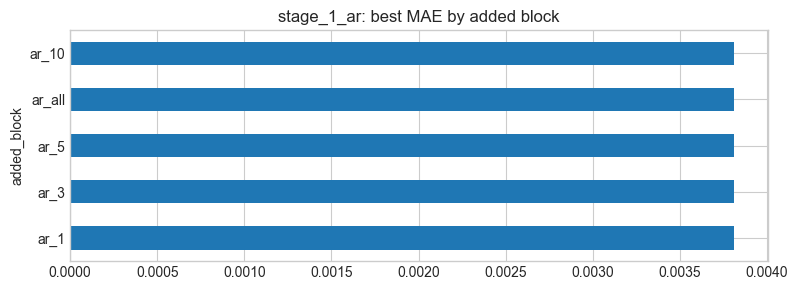

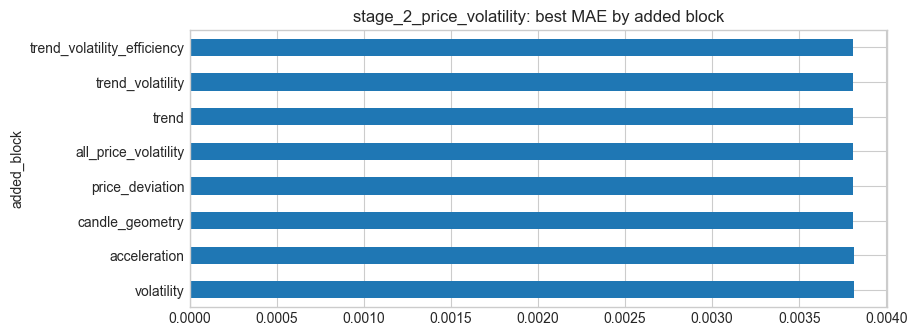

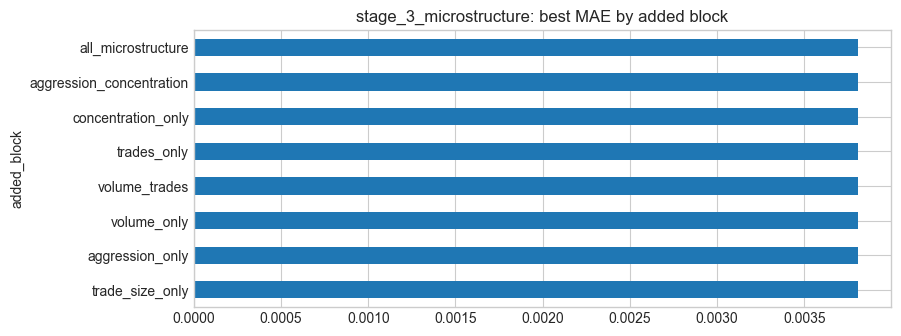

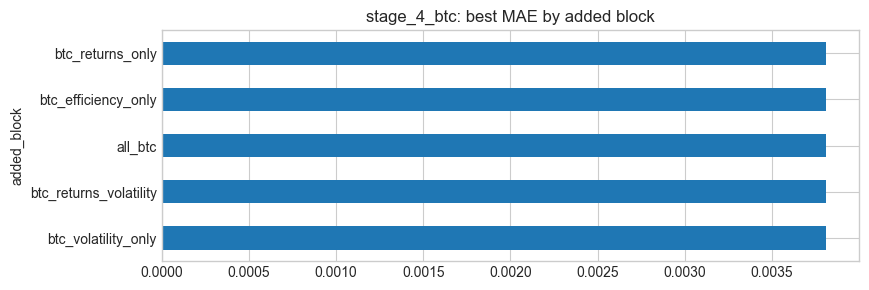

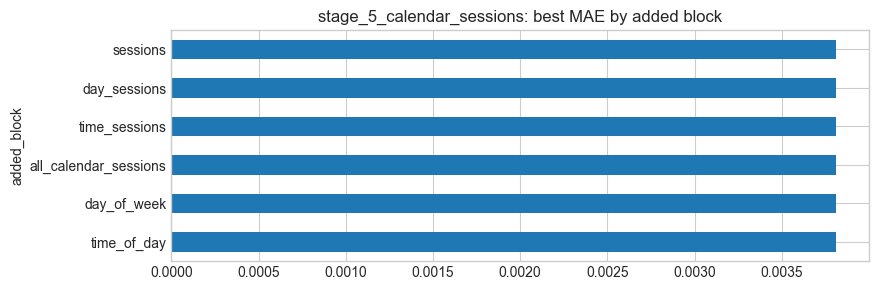

In [17]:
for stage, frame in block_summary.groupby("stage"):
    top_blocks = frame.sort_values("best_MAE").head(8)
    ax = top_blocks.plot.barh(
        x="added_block",
        y="best_MAE",
        figsize=(9, max(3, len(top_blocks) * 0.45)),
        legend=False,
        title=f"{stage}: best MAE by added block",
    )
    ax.invert_yaxis()
    plt.show()

## Selected Models By Stage

In [18]:
selected = results.loc[results["selected_for_next_stage"]].copy()
selected.sort_values(["stage", "rank_A", "rank_B"])[display_cols + ["rank_A", "rank_B", "selection_reason", "previous_model", "added_block"]]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr,rank_A,rank_B,selection_reason,previous_model,added_block
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.003814,0.007169,NaN,0.000000,0.52281,0.000000,NaN,1,2,top_A_top_B,NaN,baseline_zero
1,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.003814,0.007170,0.494714,0.492556,0.52281,-0.000047,NaN,2,1,top_A_top_B,NaN,baseline_mean
30,stage_1_ar_004_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_10,5,0.003813,0.007167,0.507209,0.508975,0.52281,0.000597,0.025433,1,11,top_A,stage_0_baseline_001_baseline_zero,ar_10
38,stage_1_ar_005_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_all,5,0.003813,0.007167,0.507209,0.508975,0.52281,0.000597,0.025433,2,12,top_A,stage_0_baseline_001_baseline_zero,ar_all
29,stage_1_ar_004_ridge_alpha_10,stage_1_ar,ridge_alpha_10,baseline_zero+ar_10,5,0.003813,0.007167,0.507675,0.509443,0.52281,0.000645,0.026387,3,9,top_A,stage_0_baseline_001_baseline_zero,ar_10
26,stage_1_ar_004_ols,stage_1_ar,ols,baseline_zero+ar_10,5,0.003813,0.007167,0.507675,0.509443,0.52281,0.000645,0.026387,9,3,top_B,stage_0_baseline_001_baseline_zero,ar_10
33,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.003814,0.007167,0.508481,0.510605,0.52281,0.000555,0.027013,16,1,top_B,stage_0_baseline_001_baseline_zero,ar_10
41,stage_1_ar_005_huber,stage_1_ar,huber,baseline_zero+ar_all,5,0.003814,0.007167,0.508481,0.510605,0.52281,0.000555,0.027013,17,2,top_B,stage_0_baseline_001_baseline_zero,ar_all
88,stage_2_price_volatility_006_elasticnet_alpha_1e_4_l1_0_5,stage_2_price_volatility,elasticnet_alpha_1e_4_l1_0_5,baseline_zero+ar_10+trend_volatility,11,0.003809,0.007112,0.515898,0.519580,0.52281,0.015880,0.171766,1,15,top_A,stage_1_ar_004_ols,trend_volatility
96,stage_2_price_volatility_007_elasticnet_alpha_1e_4_l1_0_5,stage_2_price_volatility,elasticnet_alpha_1e_4_l1_0_5,baseline_zero+ar_10+trend_volatility_efficiency,13,0.003809,0.007112,0.515898,0.519580,0.52281,0.015880,0.171766,2,16,top_A,stage_1_ar_004_ols,trend_volatility_efficiency


## Model Family Diagnostics

In [19]:
family_summary = (
    results.groupby(["stage", "model_family"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        total_fit_time=("fit_time", "sum"),
    )
    .sort_values(["stage", "best_MAE"])
)

family_summary

,stage,model_family,models,best_MAE,median_MAE,best_DA_025,median_DA_025,best_OOS_R2,total_fit_time
1,stage_0_baseline,baseline_zero,1,0.003814,0.003814,0.000000,0.000000,0.000000,8.120005e-07
0,stage_0_baseline,baseline_mean,1,0.003814,0.003814,0.492556,0.492556,-0.000047,6.901330e-04
5,stage_1_ar,lasso_alpha_1e_5,5,0.003813,0.003813,0.508975,0.507538,0.000597,3.257376e+00
9,stage_1_ar,ridge_alpha_10,5,0.003813,0.003814,0.509443,0.507806,0.000645,2.553902e+00
8,stage_1_ar,ridge_alpha_1,5,0.003813,0.003814,0.509443,0.507806,0.000645,2.258615e+00
7,stage_1_ar,ridge_alpha_0_1,5,0.003813,0.003814,0.509443,0.507806,0.000645,2.722422e+00
6,stage_1_ar,ols,5,0.003813,0.003814,0.509443,0.507806,0.000645,2.537467e+00
3,stage_1_ar,huber,5,0.003814,0.003814,0.510605,0.508525,0.000555,1.481307e+01
2,stage_1_ar,elasticnet_alpha_1e_4_l1_0_5,5,0.003814,0.003814,0.504805,0.504805,0.000216,3.731649e+00
4,stage_1_ar,lasso_alpha_1e_4,5,0.003814,0.003814,0.493046,0.493046,-0.000059,3.210621e+00


## Notes For Interpretation

- `Direction_Accuracy_025` считается только на наблюдениях, где `abs(y_true) >= 0.25%`.
- `OOS_R2` считается относительно zero baseline.
- `delta_*` считается относительно `previous_model`, то есть показывает локальный эффект добавленного блока внутри цепочки отбора.
- Финальные победители по MAE и directional accuracy могут отличаться: это ожидаемо для задачи точечной доходности.